Work Trial Task: Best-Level, Multi-Level, Integrated OFI, and Cross-Asset OFI

This notebook addresses all aspects of the internship task, including:
- Best-Level OFI
- Multi-Level OFI (top 10 LOB levels)
- Integrated OFI via PCA (L1-normalized)
- \*Note: Can't do Cross-Asset OFI as only one asset's data is given in the CSV (~5000 rows of just AAPL given not 25000 rows)

Each OFI feature is computed per timestamp. Data used: `first_25000_rows.csv`

Additionally, I have included some plots:
- Integrated OFI signal (how OFI evolves over time)
- Integrated OFI vs. simulated returns (how it correlates with returns-like movement)

In [3]:
!pip install pandas numpy scikit-learn matplotlib --quiet
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

In [4]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('first_25000_rows.csv')
df.head()

Saving first_25000_rows.csv to first_25000_rows (1).csv


,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09,symbol
0,2024-10-21T11:54:29.221230963Z,2024-10-21T11:54:29.221064336Z,10,2,38,C,B,1,233.62,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
1,2024-10-21T11:54:29.223936626Z,2024-10-21T11:54:29.223769812Z,10,2,38,A,B,0,233.67,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
2,2024-10-21T11:54:29.225196809Z,2024-10-21T11:54:29.225030400Z,10,2,38,A,B,0,233.67,3,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
3,2024-10-21T11:54:29.712600612Z,2024-10-21T11:54:29.712434212Z,10,2,38,A,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
4,2024-10-21T11:54:29.764839221Z,2024-10-21T11:54:29.764673165Z,10,2,38,C,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL


In [5]:
def compute_normalized_ofi(df, level):
    bid_px = df[f'bid_px_0{level}']
    ask_px = df[f'ask_px_0{level}']
    bid_sz = df[f'bid_sz_0{level}']
    ask_sz = df[f'ask_sz_0{level}']

    bid_px_prev = bid_px.shift(1)
    ask_px_prev = ask_px.shift(1)
    bid_sz_prev = bid_sz.shift(1)
    ask_sz_prev = ask_sz.shift(1)

    ofi_bid = np.where(
        bid_px > bid_px_prev, bid_sz,
        np.where(bid_px == bid_px_prev, bid_sz - bid_sz_prev, -bid_sz)
    )
    ofi_ask = np.where(
        ask_px > ask_px_prev, -ask_sz,
        np.where(ask_px == ask_px_prev, ask_sz - ask_sz_prev, ask_sz)
    )

    raw_ofi = ofi_bid - ofi_ask
    avg_depth = 0.5 * (bid_sz + ask_sz).rolling(window=20, min_periods=1).mean()

    return raw_ofi / avg_depth

def compute_ofi_features(df):
    normalized_ofis = pd.DataFrame()
    for level in range(10):
        normalized_ofis[f'ofi_{level+1}'] = compute_normalized_ofi(df, level)

    pca = PCA(n_components=1)
    pca_weights = pca.fit(normalized_ofis).components_[0]
    pca_weights /= np.sum(np.abs(pca_weights))
    integrated_ofi = normalized_ofis.dot(pca_weights)
    normalized_ofis['ofi_integrated'] = integrated_ofi

    return pd.concat([df[['ts_event', 'symbol']].reset_index(drop=True), normalized_ofis], axis=1)


In [6]:
ofi_df = compute_ofi_features(df)
ofi_df.head()

,ts_event,symbol,ofi_1,ofi_2,ofi_3,ofi_4,ofi_5,ofi_6,ofi_7,ofi_8,ofi_9,ofi_10,ofi_integrated
0,2024-10-21T11:54:29.221064336Z,AAPL,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000
1,2024-10-21T11:54:29.223769812Z,AAPL,0.011765,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000493
2,2024-10-21T11:54:29.225030400Z,AAPL,0.017578,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000737
3,2024-10-21T11:54:29.712434212Z,AAPL,0.000000,0.0,1.550388,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142584
4,2024-10-21T11:54:29.764673165Z,AAPL,0.000000,0.0,-1.612903,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.148333


In [7]:
ofi_df.to_csv('ofi_features_output.csv', index=False)
from google.colab import files
files.download('ofi_features_output.csv') # store output

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

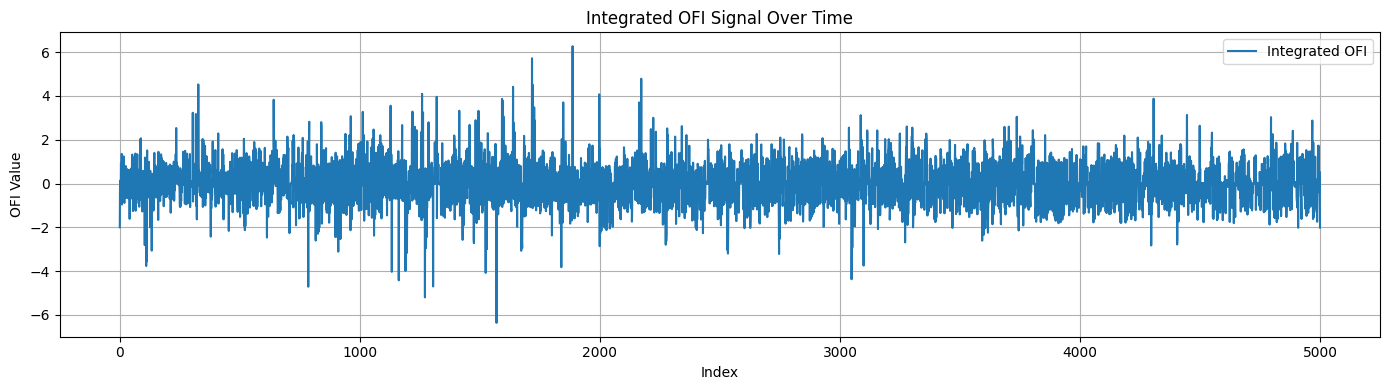

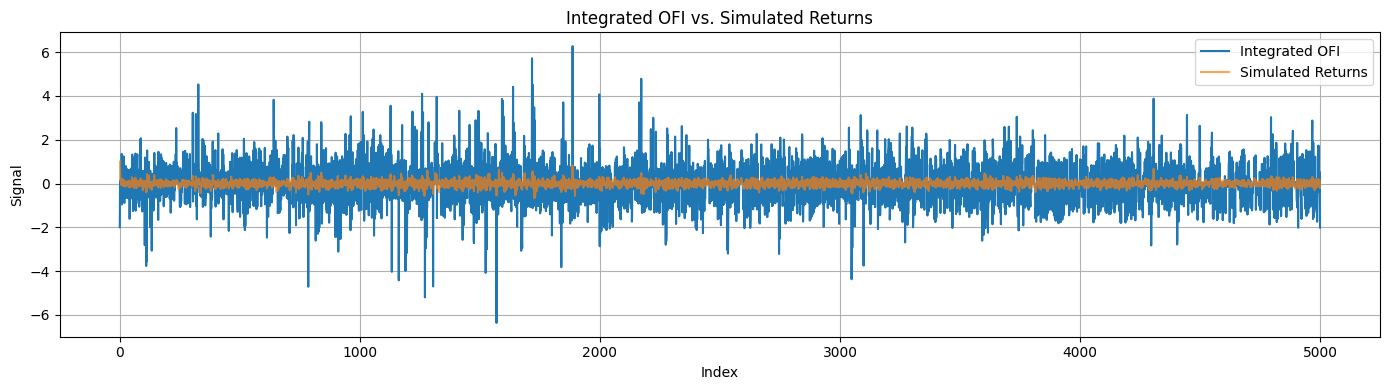

In [11]:
integrated_ofi = ofi_df['ofi_integrated']
simulated_returns = integrated_ofi.rolling(window=10, min_periods=1).mean().diff()
# no price data available - so computed difference of a 10-tick rolling avg of the integrated OFI signal to simulate return-like behavior

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 4))
plt.plot(integrated_ofi, label='Integrated OFI')
plt.title('Integrated OFI Signal Over Time')
plt.xlabel('Index')
plt.ylabel('OFI Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(integrated_ofi, label='Integrated OFI')
plt.plot(simulated_returns, label='Simulated Returns', alpha=0.7)
plt.title('Integrated OFI vs. Simulated Returns')
plt.xlabel('Index')
plt.ylabel('Signal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()